In [2]:
import math
import datetime
import numpy as np
import xarray as xr
import netCDF4 as nc
import matplotlib.pyplot as plt

mkdir -p failed for path /home/grace/.config/matplotlib: [Errno 20] Not a directory: '/home/grace/.config/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-96wy4j47 because there was an issue with the default path (/home/grace/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Bresenham Line Algorithm, which selects discrete cells to best approximate a line

In [296]:
def plotLineLow(x0, x1, y0, y1):
    ii = []
    jj = []
    dx = x1 -x0
    dy = y1 - y0    
    
    yi = 1
    if dy < 0:
        yi = -1
        dy = -dy
    y = y0
    D = (2*dy) - dx

    for x in range(x0, x1):
        ii.append(x)
        jj.append(y)
        if D > 0:
            y = y+yi
            D = D+(2*(dy-dx))
            ii.append(x)
            jj.append(y)
        else:
            D = D+2*dy
    return ii, jj

def plotLineHigh(x0, x1, y0, y1):
    ii = []
    jj = []

    dx = x1 - x0
    dy = y1 - y0
    
    xi = 1
    if dx < 0:
        xi = -1
        dx = -dx
    D = (2*dx) - dy
    x = x0

    for y in range(y0, y1):
        ii.append(x)
        jj.append(y)
        if D > 0:
            x = x+xi
            D = D + (2*(dx-dy))
            ii.append(x)
            jj.append(y)
        else:
            D = D + 2*dx
    return ii, jj

def section_calculation(x0, x1, y0, y1):
    if abs(y1-y0) < abs(x1-x0):
        if x0 > x1:
            ii, jj = plotLineLow(x1, x0, y1, y0)
        else:
            ii, jj = plotLineLow(x0, x1, y0, y1)
    else:
        if y0 > y1:
            ii, jj = plotLineHigh(x1, x0, y1, y0)
        else:
            ii, jj = plotLineHigh(x0, x1, y0, y1)
    return ii, jj, ii[::-1], jj[::-1]

        #T: are we going south or west?
        #negative=False
        #if a[j1] > a[j2]: negative = True #south
        #if a[i1] > a[i2]: negative = True #west
        
        #if negative == False: continue #just want the southward component for davis strait

In [313]:
def t_exp(ii,jj):
    mask = np.zeros((30, 30))
    
    for n in range(0,len(ii)-1):
        i1, i2, j1, j2 = int(ii[n]), int(ii[n+1]), int(jj[n]), int(jj[n+1])
        
        if j1 == j2: # G: if the movement to the next cell is purely horizontal
            mask[i1,j1] +=1 # choose v at this point
        
        elif i1 == i2: # G: otherwise (if movement to next cell is purely vertical) choose u at this point
            mask[i1,j1] +=2 # j1 - 1 for northeast flow
    return mask

In [314]:
def sec_test_plot(ii, jj, iia, jja):
    mask = t_exp(ii,jj)
    
    fig, axes = plt.subplots(1,2, figsize=(8,4))
    axes[0].pcolormesh(np.where(mask!=0, mask, np.nan), vmin = 1, vmax = 3, alpha=.7, edgecolors = 'grey',linewidth=.003)
    axes[0].plot(ii, jj, color = 'orange')
    axes[1].pcolormesh(np.where(mask!=0, mask, np.nan), vmin = 1, vmax = 3, alpha=.7, edgecolors = 'grey', linewidth=.003)
    axes[1].plot(iia, jja, color = 'orange')
    axes[0].set_title('walked forwards (x,x1,y,y1)=(' + str(ii[0]) + ',' + str(ii[-1]) + ',' +str(jj[0]) +',' + str(jj[-1]) + ')', fontsize= 10)
    axes[1].set_title('walked backwards (x,x1,y,y1)=(' + str(iia[0]) + ',' + str(iia[-1]) + ',' +str(jja[0]) +',' + str(jja[-1]) + ')', fontsize=10)
    fig.supxlabel('Purple = v, teal = u')

In [315]:
ii, jj, iib, jjb = section_calculation(28,2,2,28) # nw - se slope -1 
ii1, jj1, ii1b, jj1b = section_calculation(1, 29,11, 1) # nw - se slope > -1
ii2, jj2, ii2b, jj2b = section_calculation(1, 18,28, 1) # nw - se slope < -1

ii3, jj3, ii3b, jj3b = section_calculation(1, 29,1, 29) #sw - ne slope 1
ii4, jj4, ii4b, jj4b = section_calculation(1,25,2, 14) #sw - ne slope < 1
ii5, jj5, ii5b, jj5b = section_calculation(1,14,2, 25) #sw - ne slope > 1

ii6, jj6, ii6b, jj6b = section_calculation(15,15,2,28) #horizontal
ii7, jj7, ii7b, jj7b = section_calculation(2,28,15,15) #vertical

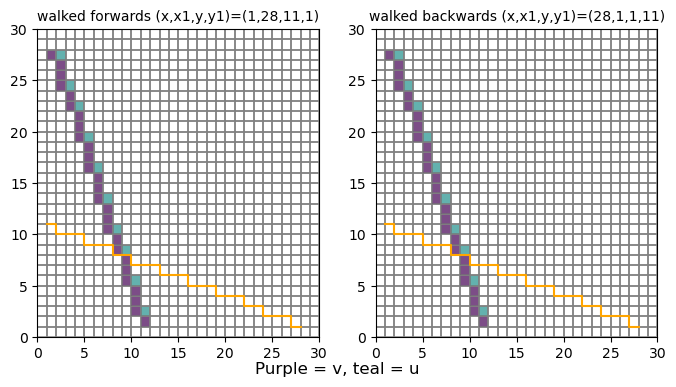

In [317]:
sec_test_plot(ii1, jj1, ii1b, jj1b)

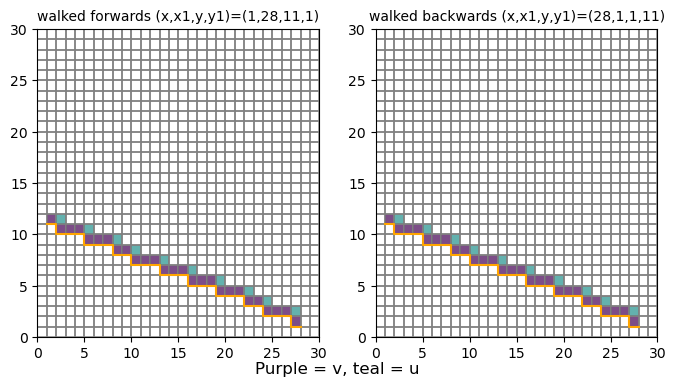

In [301]:
sec_test_plot(ii1, jj1, ii1b, jj1b)

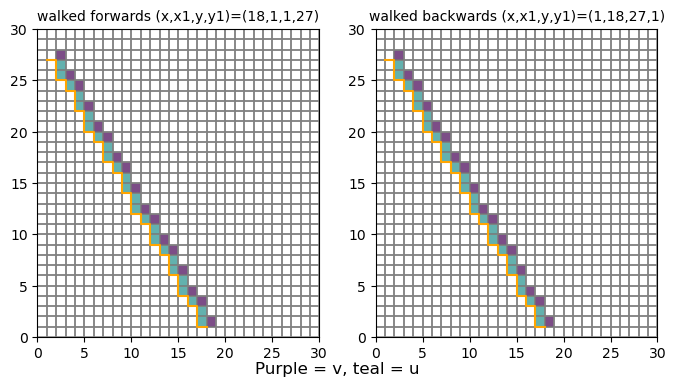

In [303]:
sec_test_plot(ii2, jj2, ii2b, jj2b)